# Study Stripping from First Principles

This follows the implementation of ``test_evolve.py`` in the SatGen repository. The code does 3 things:
1. Initialize a host halo of mass $M_{\rm UFD}$ and a single subhalo with mass $m$
2. Evolve the orbit of the subhalo in the host halo (including dynamical friction)
3. Track the mass loss of the subhalo
We initialize an NFW host halo with a virial mass of $10^9 M_\odot$ and a concentration of $11.68$. This roughly corresponds to the parameters of Segue I, which is one of the most sensitive UFD candidates. For the subhalo we take $m= 10^6 M_\odot$ as an exemplary value.

For all of this we use the SatGen routines since we eventually might also want to use it to generate the initial conditions for the system. It also has an implementation of subhalo stripping. Even though we think this description is not completely realistic and/or applicable to our scenario, it gives us a starting point to compare to.

**To Dos:**
- Run code with SatGen mass stripping and visually reproduce Tidal Tracks from [Errani et al '21](https://academic.oup.com/mnras/article/505/1/18/6271332) (this is trivial since the tidal tracks are implemented in SatGen. But it might still be useful to see that it actually matches the $v_{\rm max} - r_{\rm max}$ curve in the paper)
- Implement first order method from [Pullen et al '14](https://iopscience.iop.org/article/10.1088/0004-637X/792/1/24) (see also [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643)) numerically. See that it slightly deviates from the tidal tracks. But we should try to get it close to what it looks like in Figure 1 of [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643)
- Implement second order method from [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643), including the improved mass shell expansion formalism from [Du et al '24](http://arxiv.org/abs/2403.09597), which avoids shell crossings

**Already Done:**
- Implementation of a numeric profile class in ``subhalo_functions.py``
- A ``heat_profile`` function in ``subhalo_functions.py`` which should perform the shell expansion formalism from http://arxiv.org/abs/2403.09597 (I took it from the Fortran implementation of Galacticus https://github.com/galacticusorg/galacticus)
- An implementation of the tidal tensor computation
- A first try to perform the stripping within this file (don't trust anything... I don't think it's really working yet)

In [201]:
import config as cfg
import cosmo as co
from profiles import NFW,Dekel,Einasto,MN, Vcirc,ftot,fDF,tdyn
from orbit import orbit
import evolve as ev
import galhalo as gh

#---custom functions
import aux
from subhalo_functions import heat_profile, NumericProfile, tidalTensor

#---python modules
import numpy as np
from scipy.optimize import bisect
import time
import sys

#---for plot
import matplotlib as mpl # must import before pyplot
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

## Initialize Subhalo and Host Profile

We initialize the mass resolution, the host profile and the subhalo (including its initial phase space). The subhalo has a Dekel profile (which is the standard in SatGen)

In [209]:
cfg.Mres = 1e1

#---host properties <<< use the same as used in test_profiles.py
Mv = 10.**9. # halo virial mass [Msun]
cNFW = 11.68 # NFW concentration
#
hNFW = NFW(Mv,cNFW)
potential = hNFW
print(f"Host halo virial radius rh = {hNFW.rh:.2f} kpc, scale radius rs = {hNFW.rs:.2f} kpc")

#---satellite properties
mv0 = 10.**5.#0.1 * Mv # satellite virial mass at infall [Msun]
cDekel0 = 100. # initial concentration of satellite
aDekel0 = 1.0 + cfg.eps
#
s = Dekel(mv0,cDekel0,aDekel0)
print(f"Satellite virial radius rh = {s.rh:.2f} kpc, scale radius rs = {s.rs:.2f} kpc")

#---numeric profile of satellite
rval = np.logspace(-3,np.log10(s.rh),100)
Mval = s.M(rval)
numProfile = NumericProfile(rval, Mval)

#---initial orbit
R0 = 1
z0 = 1
# R0 = 0.8*hNFW.rh
# z0 = 0.6*hNFW.rh
phi0 = 0.
VR0 = 0.
Vphi0 = Vcirc(potential,np.sqrt(R0**2+z0**2),0.)
Vz0 = 0.
#
xv0 = np.array([R0,phi0,z0,VR0,Vphi0,Vz0])
print(f"Initial phase space vector xv0:")
print(f"  R={xv0[0]:.4f} kpc,  phi={xv0[1]:.4f} rad,  z={xv0[2]:.4f} kpc")
print(f"  VR={xv0[3]:.4f} kpc/Gyr,  Vphi={xv0[4]:.4f} kpc/Gyr,  Vz={xv0[5]:.4f} kpc/Gyr")

#---stripping parameterization
epsh = 3
gamma = 2.5

Nstep = 10000 # number of timesteps
tmax = 100. # [Gyr]


Host halo virial radius rh = 20.63 kpc, scale radius rs = 1.77 kpc
Satellite virial radius rh = 0.96 kpc, scale radius rs = 0.01 kpc
Initial phase space vector xv0:
  R=1.0000 kpc,  phi=0.0000 rad,  z=1.0000 kpc
  VR=0.0000 kpc/Gyr,  Vphi=16.7929 kpc/Gyr,  Vz=0.0000 kpc/Gyr


In [203]:
#---for evolution and bookkeeping
timesteps = np.linspace(0.,tmax,Nstep+1)[1::] #[Gyr]
print('>>> initializing ... ')
o = orbit(xv0)
r = np.sqrt(R0**2+z0**2)
m = mv0

rmax0 = s.rmax
vmax0 = s.Vmax

radius = np.zeros(Nstep)
velocity = np.zeros(Nstep)
xpos = np.zeros(Nstep)
ypos = np.zeros(Nstep)
zpos = np.zeros(Nstep)
mass = np.zeros(Nstep)
vmax = np.zeros(Nstep)
rmax = np.zeros(Nstep)
xvList = np.zeros((Nstep,6))
TidalRadius = np.zeros(Nstep)
RamPressureRadius = np.zeros(Nstep)
MassLossRate = np.zeros(Nstep)
concentration = np.zeros(Nstep)
slope = np.zeros(Nstep)
tidalHeatingRate =np.zeros(Nstep)
r_grid = np.logspace(-3,np.log10(s.rh),100)
rho_track = np.zeros((10,len(r_grid)))
M_track = np.zeros((10,len(r_grid)))

print('>>> evolving ... ')
tprevious = 0.
t1 = time.time()
tt_int = np.zeros((3,3))
tt = np.zeros((3,3))
for i,t in enumerate(timesteps):

    dt = t -  tprevious

    #---evolve orbit
    if r>cfg.Rres:
        o.integrate(t,potential,m)
        xv = o.xv
        # note that the coordinates are updated internally in the orbit
        # instance "o", here we assign them to xv only for bookkeeping
    else:
        continue
    r = np.sqrt(xv[0]**2+xv[2]**2)
    V = np.sqrt(xv[3]**2+xv[4]**2+xv[5]**2)
    x = xv[0]*np.cos(xv[1])
    y = xv[0]*np.sin(xv[1])
    z = xv[2]

    # compute the tidal heating rate (even though we don't use it here)
    t_orbit = tdyn(potential,r)
    tt = tidalTensor(potential, [x,y,z])
    tt_int += (tt -tt_int/t_orbit)*dt
    tidalHR = epsh/3*(1+(2*np.pi*r/V/t_orbit)**2)**(-gamma)*np.sum(tt * tt_int)

    #---evolve subhalo mass and profile
    if m>cfg.Mres:
        m,lt = ev.msub(s,potential,xv,dt,choice='King62',alpha=1.)
        a = s.alphah # assume: innermost slope not affected by tides
        c,Delta = ev.Dekel(m,mv0,rmax0,vmax0,aDekel0,z=0.)
    else:
        m = cfg.Mres
        lt = cfg.Rres
        c = s.ch
        a = s.alphah
    dmdt = (s.Mh - m) / dt
    s = Dekel(m,c,a,Delta=Delta,z=0.)

    #---record
    radius[i] = r
    velocity[i] = V
    mass[i] = m
    xpos[i] = x
    ypos[i] = y
    zpos[i] = z
    xvList[i,:] = xv
    TidalRadius[i] = lt
    MassLossRate[i] = dmdt
    concentration[i] = s.rh / s.rmax
    slope[i] = s.sh
    tidalHeatingRate[i] = tidalHR
    rmax[i] = s.rmax
    vmax[i] = s.Vmax

    # record the density and mass profiles for the first 10 steps
    if i<10:
        rho_track[i,:] = s.rho(r_grid)
        M_track[i,:] = s.M(r_grid)

    #---update tprevious
    tprevious = t

t2 = time.time()
print('    time = %.4f'%(t2-t1))

>>> initializing ... 
>>> evolving ... 
    time = 4.8027


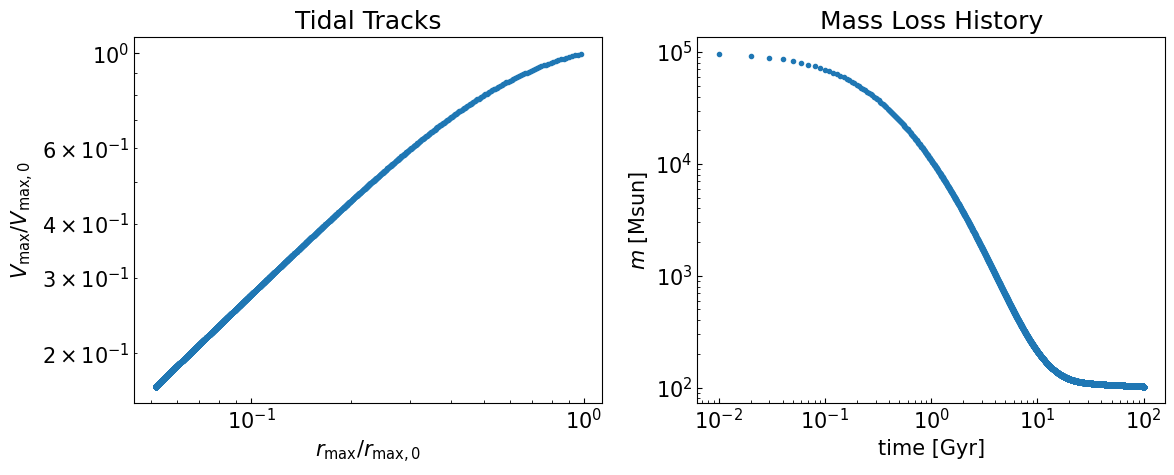

In [204]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(rmax/rmax0, vmax/vmax0,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
plt.ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
plt.title("Tidal Tracks")
plt.subplot(1,2,2)
plt.plot(timesteps, mass,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time [Gyr]')
plt.ylabel(r'$m$ [Msun]')
plt.title("Mass Loss History")

plt.tight_layout()
plt.show()

Now let us try to do the whole calculation with the custom heating procedure

In [205]:
# ---reset state so this cell is idempotent across re-runs
s = Dekel(mv0, cDekel0, aDekel0)
rval = np.logspace(np.log10(cfg.Rres), np.log10(s.rh), 100)
numProfile = NumericProfile(rval, s.M(rval))
m = mv0

n_track = 10  # number of profile snapshots to record
timesteps = np.linspace(0., tmax, Nstep+1)[1::]  # [Gyr]
print('>>> initializing ... ')
o = orbit(xv0)
r = np.sqrt(R0**2+z0**2)

rmax0N = numProfile.rmax
vmax0N = numProfile.Vmax

radiusN = np.zeros(Nstep)
velocityN = np.zeros(Nstep)
xposN = np.zeros(Nstep)
yposN = np.zeros(Nstep)
zposN = np.zeros(Nstep)
massN = np.zeros(Nstep)
vmaxN = np.zeros(Nstep)
rmaxN = np.zeros(Nstep)
xvListN = np.zeros((Nstep, 6))
TidalRadiusN = np.zeros(Nstep)
MassLossRateN = np.zeros(Nstep)
tidalHeatingRateN = np.zeros(Nstep)
r_grid = np.logspace(np.log10(cfg.Rres), np.log10(numProfile.rh), 100)
rho_trackN = np.zeros((n_track, len(r_grid)))
M_trackN = np.zeros((n_track, len(r_grid)))

# evenly-spaced snapshot indices across the full run
track_steps = np.round(np.linspace(0, Nstep - 1, n_track)).astype(int)

print('>>> evolving ... ')
tprevious = 0.
t1 = time.time()
tt_intN = np.zeros((3, 3))
ttN = np.zeros((3, 3))

for i, t in enumerate(timesteps):
    # print(f"Step {i+1}/{Nstep}, time = {t:.4f} Gyr, mass = {m:.2e} Msun, r = {r:.2f} kpc, t_orbit = {t_orbit:.4f} Gyr")

    dt = t - tprevious

    # ---evolve orbit
    if r > cfg.Rres:
        o.integrate(t, potential, m)
        xv = o.xv
        # note that the coordinates are updated internally in the orbit
        # instance "o", here we assign them to xv only for bookkeeping
    else:
        tprevious = t
        continue
    r = np.sqrt(xv[0]**2+xv[2]**2)
    V = np.sqrt(xv[3]**2+xv[4]**2+xv[5]**2)
    x = xv[0]*np.cos(xv[1])
    y = xv[0]*np.sin(xv[1])
    z = xv[2]
    t_orbit = tdyn(potential, r)
    # TODO(fabio): adaptive timesteps to guarantee dt < tdyn everywhere, otherwise we may overshoot the stripping
    # assert dt <= t_orbit, "dt is larger than the dynamical time, consider adaptative timesteps to ensure each passage through pericenter is properly captured"
    ttN = tidalTensor(potential, [x, y, z])
    tt_intN += (ttN-tt_intN/t_orbit)*dt
    tidalHRN = epsh/3*(1+(2*np.pi*r/V/t_orbit) **
                       2)**(-gamma)*np.sum(ttN * tt_intN)
    Mh_old = numProfile.Mh

    def eps(r):
        return dt*tidalHRN*r**2

    # ---evolve subhalo mass and profile
    if m > cfg.Mres:
        newProfile = heat_profile(numProfile, eps)
        lt = ev.ltidal(newProfile, potential, xv, 'King62')
        if lt < newProfile.rh:
            dm = 1. * (newProfile.Mh-newProfile.M(lt)) * \
                dt/tdyn(potential, xv[0], xv[2])
            dm = max(dm, 0.)  # avoid negative dm
            if cfg.Mres is not None:
                m = max(newProfile.Mh-dm, cfg.Mres)
            if m <= cfg.Mres:
                pass  # subhalo at mass resolution, skip profile update
            else:
                # pure bisection works here because M(r) is monotonic
                rmaxNew = bisect(lambda x: newProfile.M(x) - m, cfg.Rres, newProfile.rh)
                rvals = np.logspace(np.log10(cfg.Rres), np.log10(rmaxNew), 100)
                Mvals = newProfile.M(rvals)
                numProfile = NumericProfile(rvals, Mvals)
        else:
            numProfile = newProfile
            m = numProfile.Mh
    else:
        m = cfg.Mres
        lt = cfg.Rres
    dmdt = (Mh_old - m) / dt

    # ---record
    radiusN[i] = r
    velocityN[i] = V
    massN[i] = m
    xposN[i] = x
    yposN[i] = y
    zposN[i] = z
    TidalRadiusN[i] = lt
    MassLossRateN[i] = dmdt
    tidalHeatingRateN[i] = tidalHRN
    rmaxN[i] = numProfile.rmax
    vmaxN[i] = numProfile.Vmax

    # ---record profile at evenly-spaced snapshot steps
    slot = np.searchsorted(track_steps, i)
    if slot < n_track and track_steps[slot] == i:
        rho_trackN[slot, :] = numProfile.rho(r_grid)
        M_trackN[slot, :] = numProfile.M(r_grid)

    # ---update tprevious
    tprevious = t

t2 = time.time()
print('    time = %.4f' % (t2-t1))

>>> initializing ... 
>>> evolving ... 
    time = 9.6911


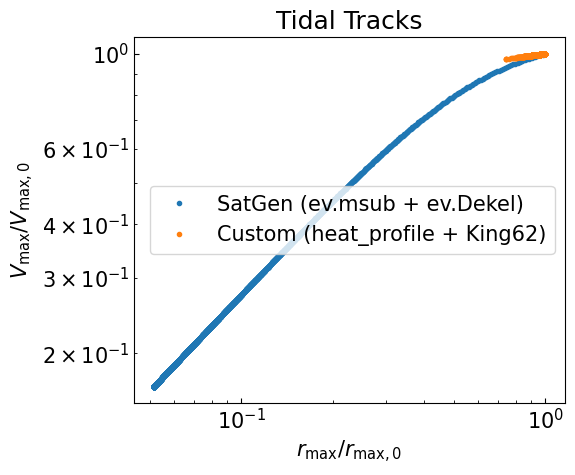

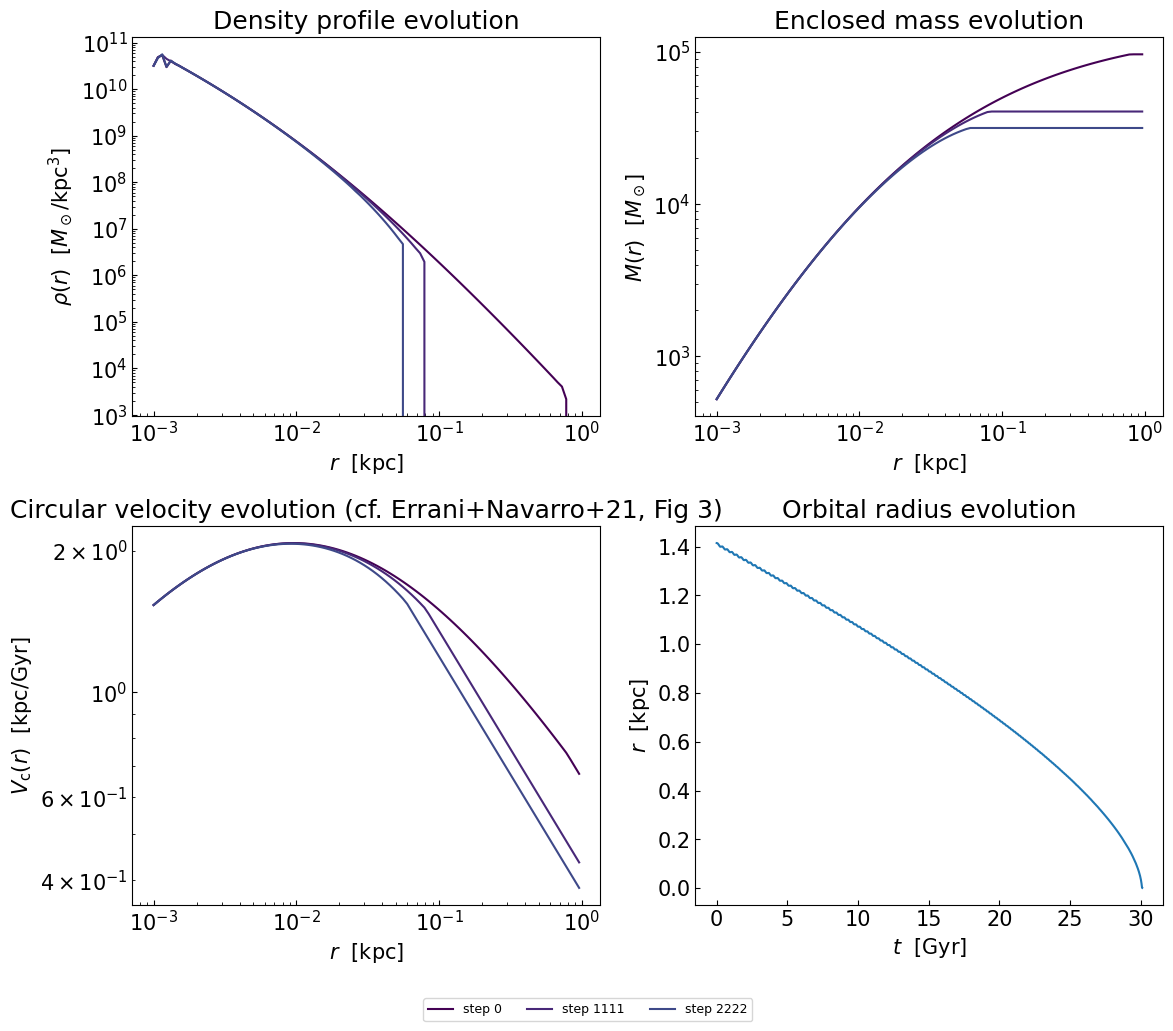

In [206]:
#---tidal tracks: SatGen baseline vs custom heat_profile
# mask unrecorded steps (arrays are zero where the step was skipped)
maskS = rmax > 0
maskN = rmaxN > 0

plt.figure(figsize=(6,5))
plt.plot(rmax[maskS]/rmax0, vmax[maskS]/vmax0, '.', label='SatGen (ev.msub + ev.Dekel)')
plt.plot(rmaxN[maskN]/rmax0N, vmaxN[maskN]/vmax0N, '.', label='Custom (heat_profile + King62)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
plt.ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
plt.title('Tidal Tracks')
plt.legend()
plt.tight_layout()
plt.show()

#---evolution of the recorded profile samples (custom procedure)
fig, axes = plt.subplots(2, 2, figsize=(12,10))
nTracks = rho_trackN.shape[0]
cmap = plt.get_cmap('viridis')

for i in range(nTracks):
    if np.all(M_trackN[i] == 0):
        continue
    c = cmap(i / max(nTracks - 1, 1))
    Vc = np.sqrt(cfg.G * M_trackN[i] / r_grid)
    label = f'step {track_steps[i]}'
    axes[0,0].plot(r_grid, rho_trackN[i], color=c, label=label)
    axes[0,1].plot(r_grid, M_trackN[i],   color=c, label=label)
    axes[1,0].plot(r_grid, Vc,            color=c, label=label)

for ax, ylab in zip([axes[0,0], axes[0,1], axes[1,0]],
                    [r'$\rho(r)$  [$M_\odot/{\rm kpc}^3$]',
                     r'$M(r)$  [$M_\odot$]',
                     r'$V_{\rm c}(r)$  [kpc/Gyr]']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$r$  [kpc]')
    ax.set_ylabel(ylab)
axes[0,0].set_title('Density profile evolution')
axes[0,1].set_title('Enclosed mass evolution')
axes[1,0].set_title(r'Circular velocity evolution (cf. Errani+Navarro+21, Fig 3)')

#---orbital radius evolution
axes[1,1].plot(timesteps[maskN], radiusN[maskN])
axes[1,1].set_xlabel(r'$t$  [Gyr]')
axes[1,1].set_ylabel(r'$r$  [kpc]')
axes[1,1].set_title('Orbital radius evolution')

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=5)
plt.tight_layout()
plt.show()

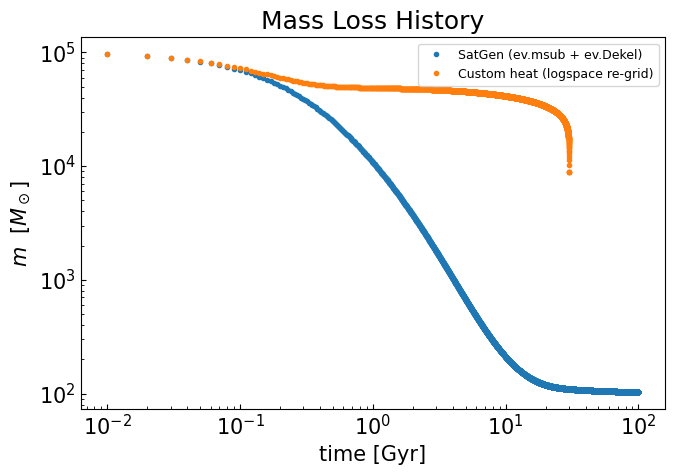

In [207]:
#---mass loss history comparison: matches style of first evolution cell
timesteps_S = np.linspace(0., tmax, Nstep+1)[1::]

maskS_t = mass > 0
maskN_t = massN > 0

plt.figure(figsize=(7, 5))
plt.plot(timesteps_S[maskS_t], mass[maskS_t],   '.', label='SatGen (ev.msub + ev.Dekel)')
plt.plot(timesteps[maskN_t],   massN[maskN_t],  '.', label='Custom heat (logspace re-grid)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time [Gyr]')
plt.ylabel(r'$m$  [$M_\odot$]')
plt.title('Mass Loss History')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()